### Basic chatbot with Langgraph(Graph API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

 - add_messages is a reducer that will add the messages to the state in the state graph

In [2]:
class State(TypedDict):
    """ Messages have the type list
    add_messages defines how the state key should be updated
    (in this case it appends the messges instead of overwriting them)

    Here this class denotes the state in the stategraph which the nodes can access
    """
    
    messages:Annotated[list, add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.chat_models import init_chat_model
from langchain_ollama import ChatOllama

llm = ChatGoogleGenerativeAI(model="google_genai:gemini-3.5-flash-lite")
llm
ollm = ChatOllama(model="ornith")
ollm

ChatOllama(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, model='ornith')

In [4]:
## Node functionality

def chatbot(state:State):
    return {"messages": [ollm.invoke(state["messages"])]}

graph_builder = StateGraph(State)

## Adding nodes
graph_builder.add_node("llmchatbot", chatbot)

## Adding edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

## compile the graph
graph = graph_builder.compile()

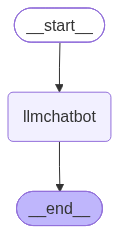

In [5]:
## Visualize the graph

from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [ ]:
response = graph.invoke({"messages":"Hi"})

In [ ]:
response["messages"][-1].content

In [ ]:
for event in graph.stream({"messages": "Hi! How are you?"}):
    for value in event.values():
        print(value)

### Chatbot with tools

In [6]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norwegian Cr

In [7]:
def multiply(a:int, b:int)->int:
    """Multiply

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [8]:
tools = [tool, multiply]

llm_with_tools = ollm.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatOllama(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, model='ornith'), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'Search query to look up', 'type': 'string'}, 'include_domains': {'anyOf': [{'items': {'type': 'string'}, 'type': 'array'}, {'type': 'null'}], 'default': [], 'description': 'A list of domains to restrict search results to.\n\n        Use this parameter when:\n        1. The user explicitly requests information from specif

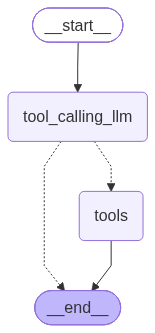

In [9]:
## Stategraph

from langgraph.graph import StateGraph
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", 
# if latest message from assistant is tool call -> tools_condition routes to tools
# if not a tool call -> routes to end
# for it to route to the "tools" perfectly, it has to be named as "tools"
tools_condition
)

builder.add_edge("tools", END)

## Compile the graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
response = graph.invoke({"messages": "What is the recent AI news"})

In [ ]:
response['messages'][-1].content 

### ReACT Agent

1. Act
2. Observe
3. Reason


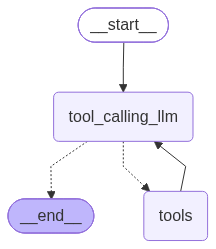

In [10]:
## ReACT Agent

from langgraph.graph import StateGraph
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", 
# if latest message from assistant is tool call -> tools_condition routes to tools
# if not a tool call -> routes to end
# for it to route to the "tools" perfectly, it has to be named as "tools"
tools_condition
)

builder.add_edge("tools", "tool_calling_llm")

builder.add_edge("tools", END)

## Compile the graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

## Adding memory in Agentic Graph

In [ ]:
response = graph.invoke({"messages":"Hello my name is Raj"})
for m in response["messages"]:
    m.pretty_print()

In [ ]:
response = graph.invoke({"messages":"What is my name?"})
for m in response["messages"]:
    m.pretty_print()

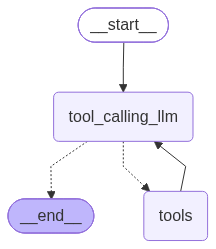

In [13]:
from langgraph.graph import StateGraph
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", 
# if latest message from assistant is tool call -> tools_condition routes to tools
# if not a tool call -> routes to end
# for it to route to the "tools" perfectly, it has to be named as "tools"
tools_condition
)

builder.add_edge("tools", "tool_calling_llm")

builder.add_edge("tools", END)

## Compile the graph
graph = builder.compile(checkpointer=memory)
 
display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
## Create a thread ID to utilize memory checkpointer

config={"configurable":{"thread_id": "1"}}
response = graph.invoke({"messages":"Hi my name is Raj"}, config=config) ## passing the configuration for the particular thread ID
response

{'messages': [HumanMessage(content='Hi my name is Raj', additional_kwargs={}, response_metadata={}, id='e1af34ae-27cb-41a3-9eba-d97438d420a2'),
  AIMessage(content='Hey Raj! Nice to meet you. How can I help?', additional_kwargs={}, response_metadata={'model': 'ornith', 'created_at': '2026-08-30T07:32:38.889928Z', 'done': True, 'done_reason': 'stop', 'total_duration': 49362223500, 'load_duration': 33939779625, 'prompt_eval_count': 1720, 'prompt_eval_duration': 13313212000, 'eval_count': 31, 'eval_duration': 2079754000, 'logprobs': None, 'model_name': 'ornith', 'model_provider': 'ollama'}, id='lc_run--01a05194-db6a-73a0-80d8-6edf71ded3c8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1720, 'output_tokens': 31, 'total_tokens': 1751})]}

In [14]:
response["messages"][-1].content

'Hey Raj! Nice to meet you. How can I help?'

In [ ]:
response = graph.invoke({"messages":"What is my name?"}, config=config)
print(response["messages"][-1].content)

## in an end-to-end one will generate the config dynamically


Your name is Raj.


## Streaming

In [14]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [18]:
def superbot(state: State):
    return {"messages":[ollm.invoke(state['messages'])]}

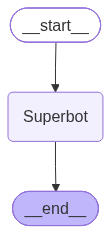

In [19]:
graph = StateGraph(State)

graph.add_node("Superbot", superbot)

graph.add_edge(START, "Superbot")
graph.add_edge("Superbot", END)

graph_builder = graph.compile(checkpointer=memory)

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [20]:
## Invokation w/o streaming

config={"configurable":{"thread_id": "1"}}
response = graph_builder.invoke({"messages":"Hi my name is Raj, I like gaming!"}, config=config) ## passing the configuration for the particular thread ID
response

{'messages': [HumanMessage(content='Hi my name is Raj, I like gaming!', additional_kwargs={}, response_metadata={}, id='cbc87e9c-cb0e-486e-9910-1a0d03e364e7'),
  AIMessage(content='Hey Raj! Nice to meet you. What kind of games do you like?', additional_kwargs={}, response_metadata={'model': 'ornith', 'created_at': '2026-09-05T08:49:17.797279Z', 'done': True, 'done_reason': 'stop', 'total_duration': 45136724541, 'load_duration': 39957869416, 'prompt_eval_count': 78, 'prompt_eval_duration': 1162136000, 'eval_count': 57, 'eval_duration': 3978756000, 'logprobs': None, 'model_name': 'ornith', 'model_provider': 'ollama'}, id='lc_run--01a070c1-518a-7b11-94de-2885b1684c38-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 78, 'output_tokens': 57, 'total_tokens': 135})]}

### Streaming

#### Methods: .stream() and astream()

Params:
 - **values**: Streams full state of graph after each node is called
 - __updates__: updates to the state of the graph after each node is called

In [21]:
config = {"configurable": {"thread_id": "3"}}
for chunk in graph_builder.stream({"messages": "Hi, My name is Raj and I like snooker!"}, config=config, stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content='Hey Raj! Nice to meet you. Snooker is a great sport — the strategy, the precision, the break-building, it all comes together beautifully. Are you a player, a fan, or both?', additional_kwargs={}, response_metadata={'model': 'ornith', 'created_at': '2026-09-05T08:49:26.393801Z', 'done': True, 'done_reason': 'stop', 'total_duration': 8275515375, 'load_duration': 8667125, 'prompt_eval_count': 99, 'prompt_eval_duration': 903351000, 'eval_count': 107, 'eval_duration': 7336919000, 'logprobs': None, 'model_name': 'ornith', 'model_provider': 'ollama'}, id='lc_run--01a070c2-031c-7053-82c8-9670ae64cfae-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 99, 'output_tokens': 107, 'total_tokens': 206})]}}


In [ ]:
for chunk in graph_builder.stream({"messages": "Hi, My name is Raj and I like snooker!"}, config=config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Raj and I like snooker!', additional_kwargs={}, response_metadata={}, id='fba07709-ef99-43f1-9f9c-1922671dec35'), HumanMessage(content='Hi, My name is Raj and I like snooker!', additional_kwargs={}, response_metadata={}, id='9aeb4425-3166-4c8b-a8fe-3a0b35a2263a'), AIMessage(content='Hey Raj! Nice to meet you. Snooker is a great sport — the strategy, the precision, the break-building, it all comes together beautifully. Are you a player, a fan, or both?', additional_kwargs={}, response_metadata={'model': 'ornith', 'created_at': '2026-09-05T08:49:26.393801Z', 'done': True, 'done_reason': 'stop', 'total_duration': 8275515375, 'load_duration': 8667125, 'prompt_eval_count': 99, 'prompt_eval_duration': 903351000, 'eval_count': 107, 'eval_duration': 7336919000, 'logprobs': None, 'model_name': 'ornith', 'model_provider': 'ollama'}, id='lc_run--01a070c2-031c-7053-82c8-9670ae64cfae-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_

In [24]:
config = {"configurable": {"thread_id": "4"}}
async for event in graph_builder.astream_events({"messages": "Hi, My name is Raj and I like snooker!"}, config=config, version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi, My name is Raj and I like snooker!'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a072d6-55ba-76f1-8ed2-60bdb8fea5a8', 'metadata': {'thread_id': '4', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, My name is Raj and I like snooker!', additional_kwargs={}, response_metadata={}, id='e7a74362-4f90-4e3d-b2cb-6f950a103231')]}}, 'name': 'Superbot', 'tags': ['graph:step:1'], 'run_id': '01a072d6-55c3-7841-b10b-3d27295f8e53', 'metadata': {'thread_id': '4', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'Superbot', 'langgraph_triggers': ('branch:to:Superbot',), 'langgraph_path': ('__pregel_pull', 'Superbot'), 'langgraph_checkpoint_ns': 'Superbot:061f2cc8-0b81-9b5a-e8c4-e1bbe5717001'}, 'parent_ids': ['01a072d6-55ba-76f1-8ed2-60bdb8fea5a8']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(co